In [1]:
using Revise
using SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.TwoMMs
using SSMCMain.ModifiedMiCRM.FFTAnalysis
# includet("../../../scripts/single_influx.jl")

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack
using Base.Threads
using FFTW
using Optim

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

In [4]:
includet("../../scripts/single_influx.jl")

# Testing 1

In [465]:
mean(rsg.K) * mean(rsg.c) / (mean(rsg.m) * mean(rsg.r))

15.0

In [ ]:
mean(rsg.Dr) / mean(rsg.Drinflux)

1.0

In [456]:
K = 15.
l = 1.

DN = 1e-6
p = 1.

N = 20
M = 20

T = 1e8
tol = 1e-8

rsg = get_si_sampler_for_paper(K, l, DN;
    N, M,
    DR=p
)

mmp = MMParams(;
    K, l,
    m=1., c=1.,
    # d=0.5,
);
mm_Ds = [DN, 1., p];

In [360]:
mm_ps = mmp_to_mmicrm(mmp; static=false)

mm_u0 = [1., 0., 0.]
mm_p = make_mmicrm_problem(mm_ps, mm_u0, T)
@time mm_s = solve(mm_p, QNDF();
    callback=make_timer_callback(10.),
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(mm_s), mm_s.u[end];
mm_fs = mm_s.u[end];

  0.011954 seconds (1.50 k allocations: 135.344 KiB)
(mmicrmmaxresid(mm_s), mm_s.u[end]) = (0.0, [12.922616289332565, 1.0773837106674355, 1.0])


In [361]:
gen_ps = rsg()
si_ps = gen_ps.mmicrm_params
si_Ds = gen_ps.Ds

si_u0 = [fill(1., N); fill(0., M)]
si_p = make_mmicrm_problem(si_ps, si_u0, T)
@time si_s = solve(si_p, QNDF();
    callback=make_timer_callback(10.),
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(si_s) count(>(1e-9), si_s.u[end][1:N]);
si_fs = si_s.u[end];

  0.038096 seconds (1.54 k allocations: 524.172 KiB)
mmicrmmaxresid(si_s) = 2.4424906541753444e-15
count((>)(1.0e-9), (si_s.u[end])[1:N]) = 4


In [362]:
ks = 10 .^ range(-6, 2, 1000)
mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)
si_mrls = linstab_simple(si_ps, si_Ds, si_fs, ks);

In [364]:
maximum(mm_mrls)

0.0010624851652210054

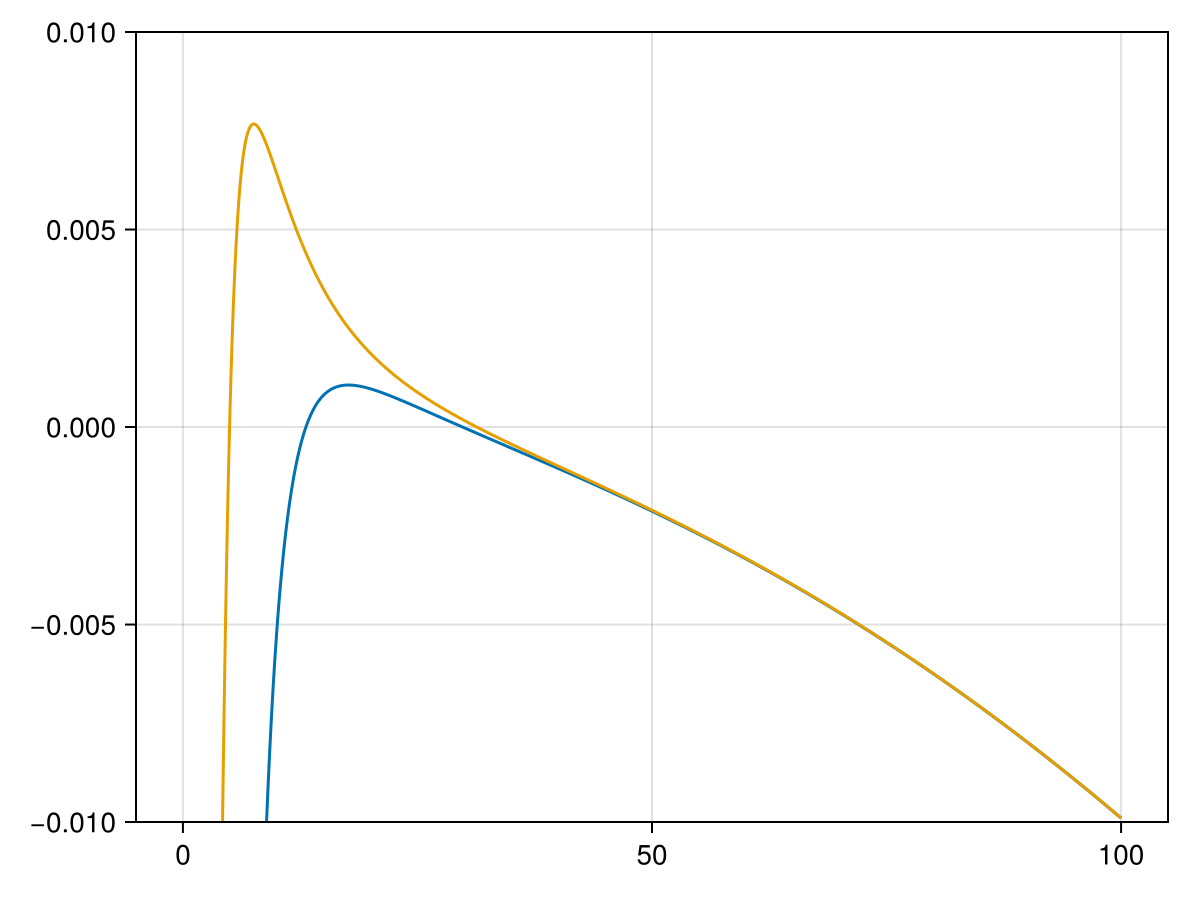

In [363]:
fig = Figure()
ax = Axis(fig[1,1])

lines!(ks, mm_mrls)
lines!(ks, si_mrls)

ylims!(ax, -1e-2, 1e-2)
# display(GLMakie.Screen(), fig)
fig

# Optimizing the MM s

## A single run

In [67]:
K = 50.
l = 0.99

DN = 0.
p = 1.

N = 20
M = 20

T = 1e8
tol = 1e-8

rsg = get_si_sampler_for_paper(K, l, DN;
    N, M,
    DR=p
)

JansSampler3(20, 20, LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=1.0), Dirac{Int64}(value=1), Dirac{Float64}(value=50.0), 0.15, 1.0, Binomial{Float64}(n=20, p=0.15), LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=0.0), LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=0.99), Dirac{Float64}(value=0.0), Dirac{Float64}(value=1.0), Dirac{Float64}(value=1.0), nothing)

In [80]:
gen_ps = rsg()
si_ps = gen_ps.mmicrm_params
si_Ds = gen_ps.Ds

si_u0 = [fill(1., N); fill(0., M)]
si_p = make_mmicrm_problem(si_ps, si_u0, T)
@time si_s = solve(si_p, QNDF();
    callback=CallbackSet(make_timer_callback(10.), PositiveDomain(si_u0)),
    abstol=tol,
    reltol=tol,
)
si_num_surv = count(>(1e-9), si_s.u[end][1:N]);
@show mmicrmmaxresid(si_s) si_num_surv;
si_fs = si_s.u[end];

 10.000042 seconds (2.05 M allocations: 635.043 MiB, 3.64% gc time)
mmicrmmaxresid(si_s) = 4.800999597875943e-10
si_num_surv = 6


In [84]:
mm_Ds = [DN, 1., p];
mm_u0 = [1., 0., 0.]

# ks = 10 .^ range(-6, 2, 1000)
# ks = 10 .^ range(-2, 5, 1000)
ks = range(0.01, 10000, 1000)
si_mrls = linstab_simple(si_ps, si_Ds, si_fs, ks);

opt_r = optimize([1.]) do u
    mm_d = u[1]
    mmp = MMParams(;
        K, l,
        m=1., c=1.,
        d=mm_d,
    );
    mm_ps = mmp_to_mmicrm(mmp; static=false)

    mm_p = make_mmicrm_problem(mm_ps, mm_u0, T)
    mm_s = solve(mm_p, QNDF();
        callback=make_timer_callback(10.),
        abstol=tol,
        reltol=tol,
    )
    mm_fs = mm_s.u[end];
    mresid = mmicrmmaxresid(mm_s)
    if (mresid > 1e-9) || (mm_fs[1] < 1e-9)
        return Inf
    end

    mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)
    # sum(abs2, mm_mrls .- si_mrls)
    abs(maximum(mm_mrls) - maximum(si_mrls))
end;

In [85]:
mm_d = opt_r.minimizer[1]
# mm_d = 0.5
mmp = MMParams(;
    K, l,
    m=1., c=1.,
    d=mm_d,
);
mm_Ds = [DN, 1., p];

mm_ps = mmp_to_mmicrm(mmp; static=false)

mm_u0 = [1., 0., 0.]
mm_p = make_mmicrm_problem(mm_ps, mm_u0, T)
@time mm_s = solve(mm_p, QNDF();
    callback=make_timer_callback(10.),
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(mm_s), mm_s.u[end];
mm_fs = mm_s.u[end];

  0.000622 seconds (1.74 k allocations: 153.750 KiB)
(mmicrmmaxresid(mm_s), mm_s.u[end]) = (1.259749637938512e-9, [47.98958107174055, 1.0206251800335355, 0.9897937482259151])


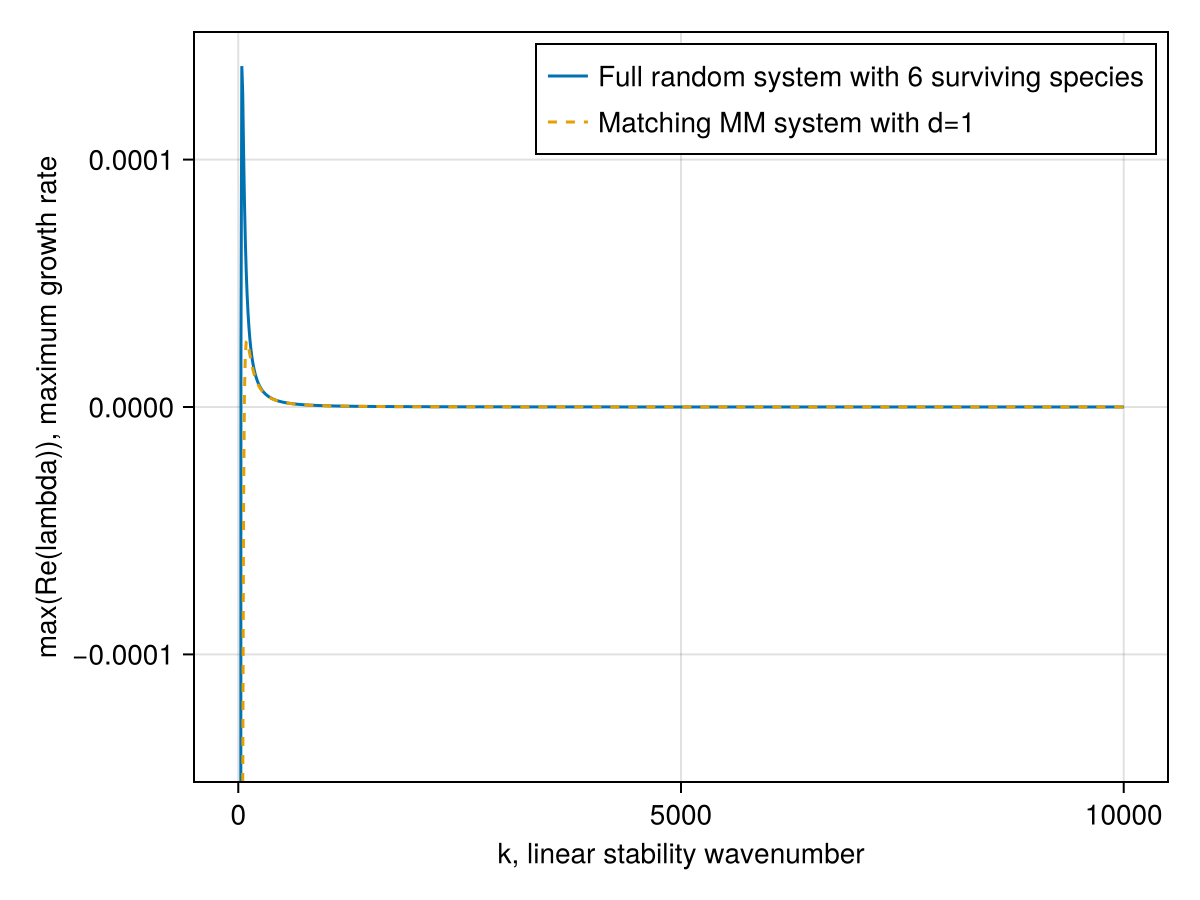

In [86]:
mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)

fig = Figure()
ax = Axis(fig[1,1];
    xlabel="k, linear stability wavenumber",
    ylabel="max(Re(lambda)), maximum growth rate",
)

lines!(ks, si_mrls; label=(@sprintf "Full random system with %d surviving species" si_num_surv))
lines!(ks, mm_mrls; label=(@sprintf "Matching MM system with d=%.3g" mm_d), linestyle=:dash)

axislegend(ax)

# ylims!(ax, -1e-2, 1e-2)
ylims!(ax, (abs(maximum(si_mrls)) .* (-1.1, 1.1))...)
# display(GLMakie.Screen(), fig)
fig

## Many runs

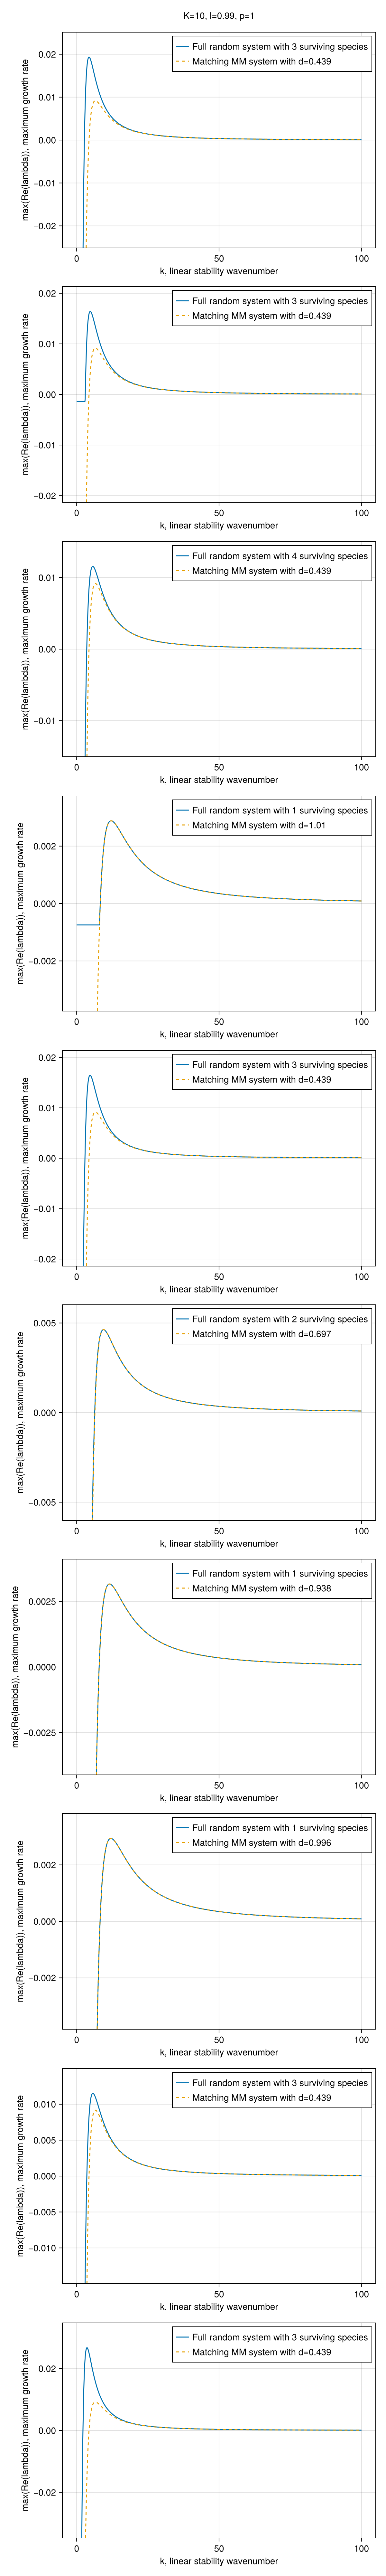

In [5]:
num_runs = 10

K = 10.
l = 0.99

DN = 0.
p = 1.

N = 20
M = 20

T = 1e8
tol = 1e-8

rsg = get_si_sampler_for_paper(K, l, DN;
    N, M,
    DR=p
)

si_u0 = [fill(1., N); fill(0., M)]
mm_Ds = [DN, 1., p];
mm_u0 = [1., 0., 0.]

# ks = 10 .^ range(-6, 2, 1000)
ks = range(0.01, 100, 1000)
# ks = range(100., 10000000., 1000)

fig = Figure(;
    size=(600, 400 * num_runs)
)

i = 1
while i <= num_runs
    gen_ps = rsg()
    si_ps = gen_ps.mmicrm_params
    si_Ds = gen_ps.Ds

    si_p = make_mmicrm_problem(si_ps, si_u0, T)
    si_s = solve(si_p, QNDF();
        callback=CallbackSet(make_timer_callback(10.), PositiveDomain(si_u0)),
        abstol=tol,
        reltol=tol,
    )
    si_fs = si_s.u[end];
    si_num_surv = count(>(1e-9), si_fs[1:N]);
    if si_num_surv == 0
        continue
    end
    si_mrls = linstab_simple(si_ps, si_Ds, si_fs, ks);

    opt_r = optimize([1.]) do u
        mm_d = u[1]
        mmp = MMParams(;
            K, l,
            m=1., c=1.,
            d=mm_d,
        );
        mm_ps = mmp_to_mmicrm(mmp; static=false)

        mm_p = make_mmicrm_problem(mm_ps, mm_u0, T)
        mm_s = solve(mm_p, QNDF();
            callback=make_timer_callback(10.),
            abstol=tol,
            reltol=tol,
        )
        mm_fs = mm_s.u[end];
        mresid = mmicrmmaxresid(mm_s)
        if (mresid > 1e-9) || (mm_fs[1] < 1e-9)
            return Inf
        end

        mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)
        # sum(abs2, mm_mrls .- si_mrls)
        abs(maximum(mm_mrls) - maximum(si_mrls))
    end;

    mm_d = opt_r.minimizer[1]
    # mm_d = 1.
    mmp = MMParams(;
        K, l,
        m=1., c=1.,
        d=mm_d,
    );
    mm_Ds = [DN, 1., p];

    mm_ps = mmp_to_mmicrm(mmp; static=false)

    mm_u0 = [1., 0., 0.]
    mm_p = make_mmicrm_problem(mm_ps, mm_u0, T)
    mm_s = solve(mm_p, QNDF();
        callback=make_timer_callback(10.),
        abstol=tol,
        reltol=tol,
    )
    # @show mmicrmmaxresid(mm_s), mm_s.u[end];
    mm_fs = mm_s.u[end];

    mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)

    ax = Axis(fig[i,1];
        xlabel="k, linear stability wavenumber",
        ylabel="max(Re(lambda)), maximum growth rate",
    )

    lines!(ks, si_mrls; label=(@sprintf "Full random system with %d surviving species" si_num_surv ))
    lines!(ks, mm_mrls; label=(@sprintf "Matching MM system with d=%.3g" mm_d), linestyle=:dash)

    axislegend(ax)
    
    # ylims!(ax, -5e-8, 5e-7)
    ylims!(ax, (abs(maximum(si_mrls)) .* (-1.3, 1.3))...)
    # ylims!(ax, (extrema(si_mrls) .* 1.1)...)

    i += 1
end

Label(fig[0,:], (@sprintf "K=%.3g, l=%.3g, p=%.3g" K l p); tellwidth=false)
# Makie.save("./mm_si_disprels/opt_K$(K)_l$(l)_p$(p).pdf", fig)
# Makie.save("./mm_si_disprels/base_d1_K$(K)_l$(l)_p$(p).pdf", fig)

fig


# Old for reference

In [5]:
rsg = get_si_sampler_for_paper(15, 1., 1e-6;
    DR=1.
)

JansSampler3(20, 20, LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=1.0), Dirac{Int64}(value=1), Dirac{Int64}(value=15), 0.15, 1.0, Binomial{Float64}(n=20, p=0.15), LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=0.0), LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=1.0), Dirac{Float64}(value=1.0e-6), Dirac{Float64}(value=1.0), Dirac{Float64}(value=1.0), nothing)

In [6]:
gen_ps = rsg()
ode_ps = gen_ps.mmicrm_params
N, M = get_Ns(ode_ps)

T = 1e8
tol = 1e-8

ode_u0 = [fill(1., N); fill(0., M)]
ode_p = make_mmicrm_problem(ode_ps, ode_u0, T)
ode_s = solve(ode_p, QNDF();
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(ode_s) ode_s.u[end];

mmicrmmaxresid(ode_s) = 2.0883528157543656e-15
ode_s.u[end] = [-6.996901409336271e-29, -4.515914345313423e-40, -6.963025135752165e-16, -1.3388113695137215e-46, -5.0013055548753233e-29, 7.573672517121472e-31, 4.4597991336682474e-29, -4.8894052510223425e-52, -4.42138386295722e-30, 1.1376349842917901e-27, 6.303506984005407e-68, -1.612747717399046e-30, 4.029895408169709e-42, -6.492261007632364e-39, 6.102053056076085e-68, -8.890344016365901e-40, -2.011005918942206e-40, 6.167258809333767e-68, 12.914018107205944, 2.760720300441803e-43, -3.3668513670696607e-31, 1.698637148888672e-29, 5.169273095889309e-28, 6.402753837215697e-23, 5.486183105807093e-28, -1.216708050079071e-29, 6.374158938197673e-24, -1.686942601595637e-16, 9.89794969745064e-31, -3.098565437491132e-16, 5.398929931669416e-31, 1.0787041665250712, -1.7908189674129898e-29, 0.3679268301264261, 0.0, -4.1954298419555893e-29, 0.6301967376658436, -1.487746624597631e-28, 1.2853590882951067e-29, 4.066534447958056e-29]


In [7]:
L = 10
sN = 2500

epsilon = 1e-6

u0 = expand_u0_to_size((sN,), ode_s.u[end])
u0 = perturb_u0_uniform(N, M, u0, epsilon)

# meanN0, numwaves, waveampfactor = 1.0, 100, 100.0
# u0 = get_siny_u0(1, 2, sN, dx, meanN0, numwaves, waveampfactor)

dx = L / sN

pde_ps = change_bsmmicrmparams(gen_ps;
    space=CartesianSpace{1, Tuple{Periodic}}([dx]),
    usenthreads=nthreads(),
)
pde_p = make_smmicrm_problem(pde_ps, u0, T);
@time pde_s = solve(pde_p, QNDF();
    # callback=make_timer_callback(3 * 60),
    # callback=CallbackSet(make_timer_callback(1 * 60), make_fft_callback2(N, sN, dx, 200)),
    callback=CallbackSet(make_timer_callback(2 * 60), make_perturb_callback2(sN, ode_s.u[end], 2.)),
    abstol=tol,
    reltol=tol,
);
@show smmicrmmaxresid(pde_s);
pde_s.retcode

 39.887810 seconds (8.56 M allocations: 15.892 GiB, 1.76% gc time, 21.08% compilation time)
smmicrmmaxresid(pde_s) = 0.0021091172876373855


ReturnCode.Terminated = 2

## Linear stability

kmax = 7.94145171902934
mrlmax = 0.006908673530098619


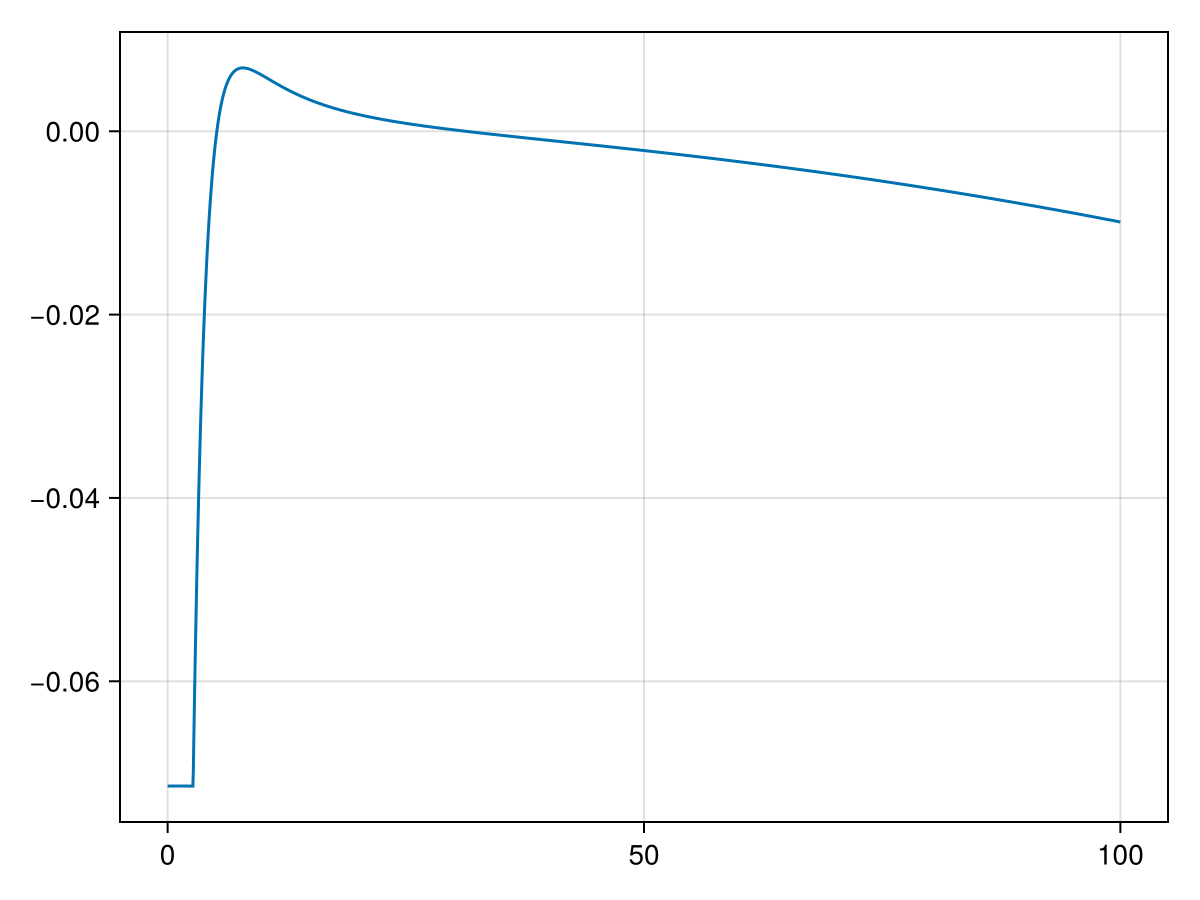

In [222]:
ks = 10 .^ range(-5, 2, 1000)
mrls = linstab_simple(ode_ps, pde_ps.Ds, ode_s.u[end], ks)

mrlmax, iii = findmax(mrls)
kmax = ks[iii]

@show kmax mrlmax

lines(ks, mrls)

## Looking at the power spectrum in time

In [220]:
dd = 30
iii = findmax(xxx[:,end])[2]
(xxx[iii,end] - xxx[iii,end-dd]) / (pde_s.t[end] - pde_s.t[end-dd])

0.0026827152691225515

In [232]:
maxxxxe / exp(mrlmax * pde_s.t[end])

2.6472159217857684e-7

In [225]:
pde_s.t[3]

9.641828782510668e-14

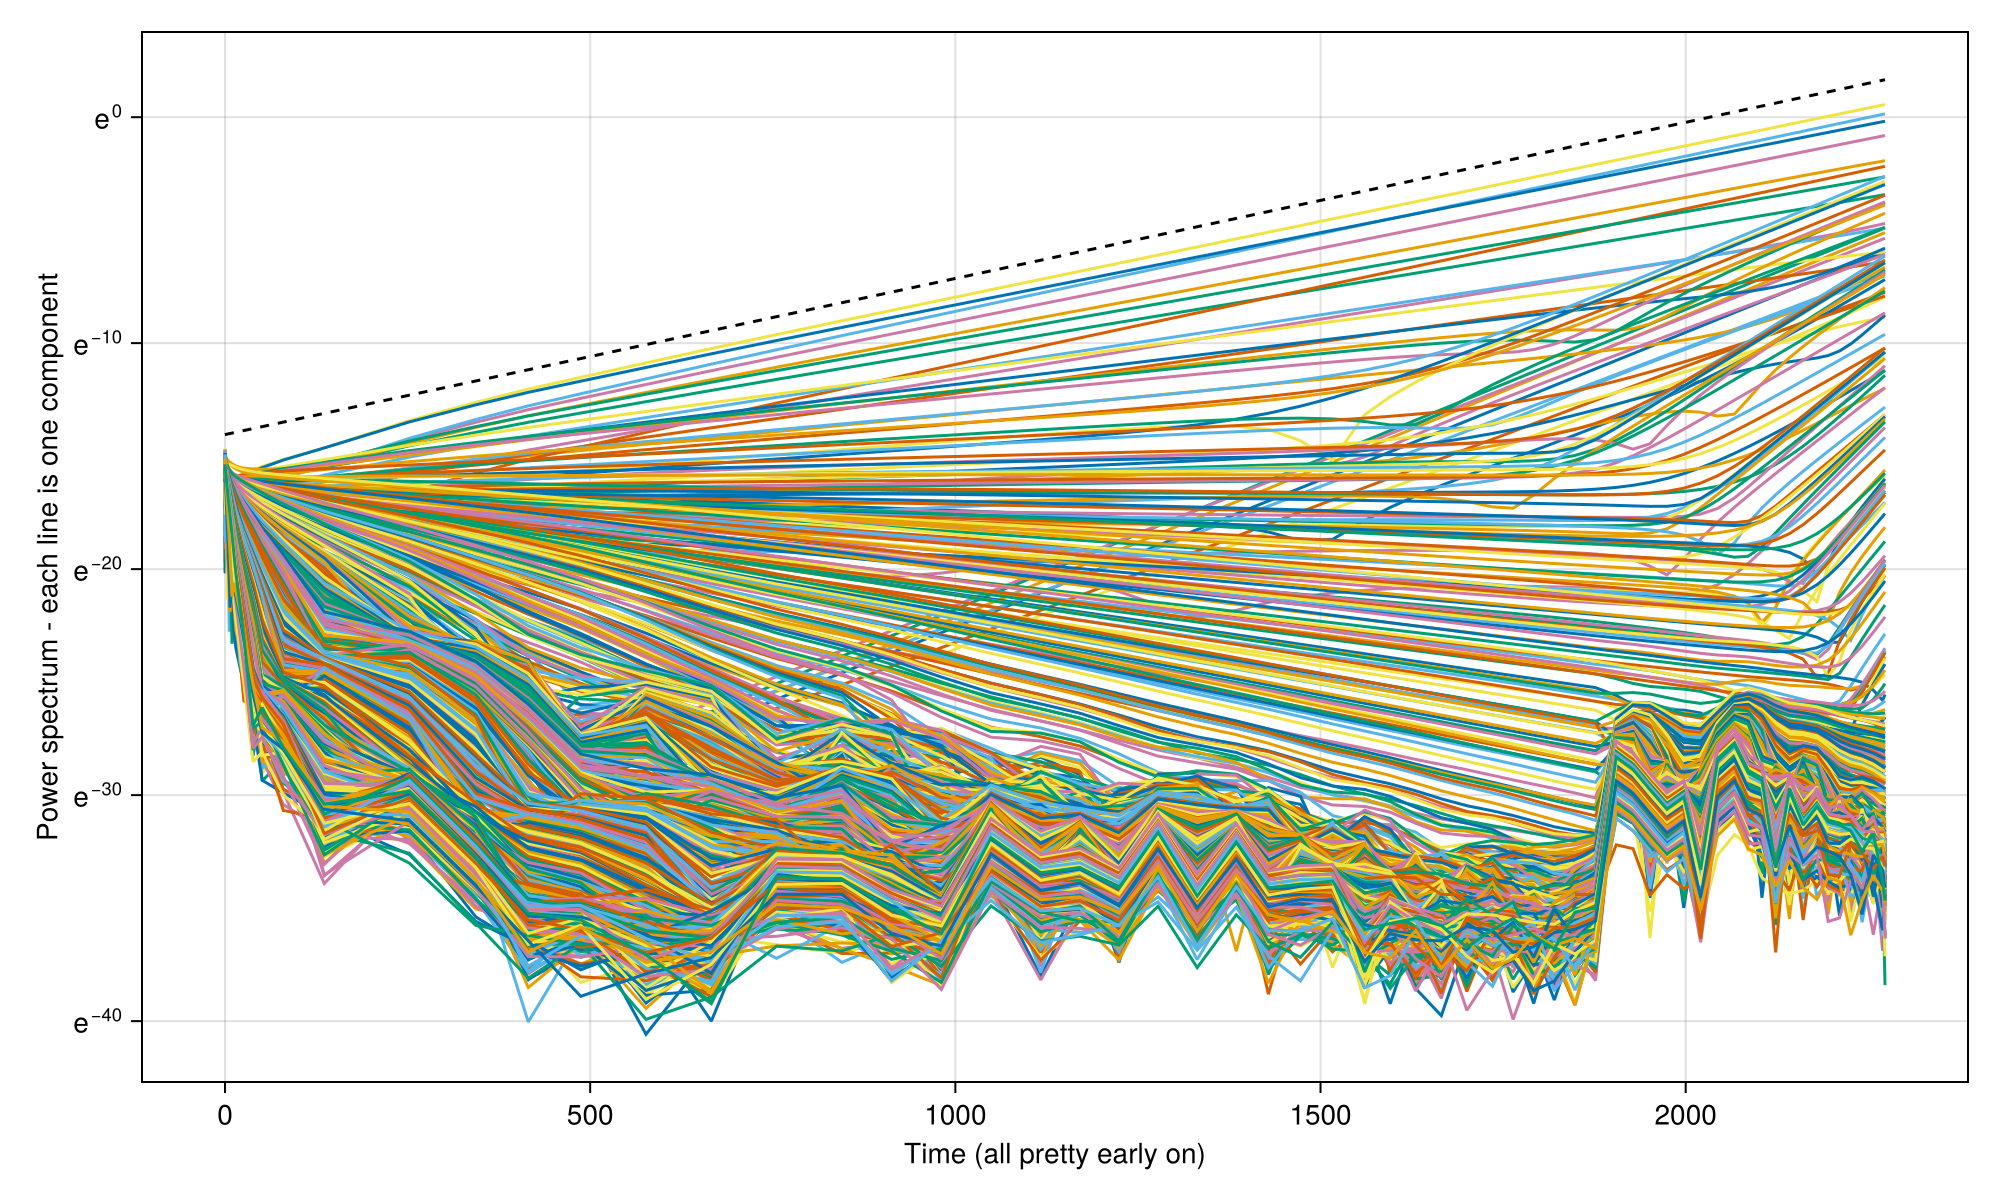

In [241]:
xxx = hcat(get_sp.(get_total_biomass_1d.(pde_s.u, N), dx)...)
fig = Figure(; size=(1000, 600))
ax = Axis(fig[1,1];
    yscale=log,
    xlabel="Time (all pretty early on)",
    ylabel="Power spectrum - each line is one component",
)

for i in 1:size(xxx, 1)
    lines!(ax, pde_s.t, xxx[i,:];
        # marker=:cross,
    )
end

maxxxxe = maximum(xxx[:,end]) * 3
bb = maxxxxe / exp(mrlmax * pde_s.t[end])
lines!(pde_s.t, bb .* exp.(pde_s.t .* mrlmax); color=:black, linestyle=:dash)

# display(GLMakie.Screen(), fig)
Makie.save("./power_spectrum_in_time_si.pdf", fig)

fig